In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


ModuleNotFoundError: No module named 'Path'

In [47]:
plasma_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\proteomics data, removed poor QC samples.xlsx"
plasma_labels_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\Proteomics sample labels.csv"
plasma_clinical_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\20241126 Sample ordering and info.xlsx"

In [6]:
tissue_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\tissue\PrOEF-250303-OPL3026-TSB-DIA_Protein.Profiling-Human.Abdominal.Aorta.Tissue.(Abdominal.Aortic.Aneurysm).xlsx"
tissue_clinical_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\tissue\Clinical Data MACE Amsterdam VA.xlsx"

In [12]:
df_tissue = pd.read_excel(tissue_dir, sheet_name='protein report')

In [13]:
print(df_tissue.columns)

Index(['Protein.Group', 'Protein.Names', 'Genes',
       'Log2 intensity (S001) AAA_Diabetes_Smoker_(1)',
       'Log2 intensity (S002) AAA_Diabetes_(2)',
       'Log2 intensity (S003) Control_(3)',
       'Log2 intensity (S004) AAA_Smoker_(4)',
       'Log2 intensity (S007) AAA_Smoker_(7)',
       'Log2 intensity (S011) AAA_Diabetes_Metformin_Smoker_(11)',
       'Log2 intensity (S012) AAA_Diabetes_(12)',
       ...
       'Log2 intensity (S079) AAA_Smoker_(79)',
       'Log2 intensity (S080) AAA_Smoker_(80)',
       'Log2 intensity (S081) AAA_(81)',
       'Log2 intensity (S087) AAA_Smoker_(87)',
       'Log2 intensity (S091) AAA_Smoker_(91)',
       'Log2 intensity (S093) AAA_(93)',
       'Log2 intensity (S095) AAA_Diabetes_Metformin_Smoker_(95)',
       'Log2 intensity OPL3026_HeLa50ng_07', 'Log2 intensity (S006) AAA_(6)',
       'Log2 intensity (S084) AAA_Smoker_(84)'],
      dtype='str', length=107)


In [14]:
df_tissue.head(10)

,Protein.Group,Protein.Names,Genes,Log2 intensity (S001) AAA_Diabetes_Smoker_(1),Log2 intensity (S002) AAA_Diabetes_(2),Log2 intensity (S003) Control_(3),Log2 intensity (S004) AAA_Smoker_(4),Log2 intensity (S007) AAA_Smoker_(7),Log2 intensity (S011) AAA_Diabetes_Metformin_Smoker_(11),Log2 intensity (S012) AAA_Diabetes_(12),...,Log2 intensity (S079) AAA_Smoker_(79),Log2 intensity (S080) AAA_Smoker_(80),Log2 intensity (S081) AAA_(81),Log2 intensity (S087) AAA_Smoker_(87),Log2 intensity (S091) AAA_Smoker_(91),Log2 intensity (S093) AAA_(93),Log2 intensity (S095) AAA_Diabetes_Metformin_Smoker_(95),Log2 intensity OPL3026_HeLa50ng_07,Log2 intensity (S006) AAA_(6),Log2 intensity (S084) AAA_Smoker_(84)
0,Q16585,SGCB_HUMAN,SGCB,9.065723,8.804035,10.121942,8.103925,7.547642,8.372846,8.259260,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P51608-2,MECP2_HUMAN,MECP2,9.233215,8.649819,10.810051,9.461354,8.213499,9.181561,9.318148,...,6.590036,NaN,7.613278,5.974929,NaN,6.578975,NaN,8.069332,6.773532,6.396201
2,Q9H3H3,CK068_HUMAN,C11orf68,9.866450,9.624528,8.357053,9.350256,8.462160,9.632663,9.606487,...,8.897010,NaN,NaN,7.205819,NaN,7.817692,NaN,9.130469,6.774161,7.462926
3,Q6ZT12;Q6ZT12-4,UBR3_HUMAN,UBR3,7.386442,7.298594,7.382471,7.472147,NaN,7.684338,7.756356,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.340680,NaN,NaN
4,Q96P70,IPO9_HUMAN,IPO9,9.011502,9.441655,8.578271,9.246102,8.908170,9.363126,9.523079,...,8.814127,6.376397,6.931440,7.439738,8.585849,8.410148,6.141470,10.378998,6.955465,8.932941
5,P28482,MK01_HUMAN,MAPK1,10.658939,10.520296,9.887492,10.029530,9.482227,10.376157,10.691150,...,8.985089,6.120840,NaN,7.927546,8.989349,8.351524,6.475787,9.124777,7.022609,8.604738
6,P09417,DHPR_HUMAN,QDPR,10.372409,10.144292,9.269636,9.814182,9.874579,10.401876,10.427273,...,8.684503,7.537254,NaN,7.955149,8.130974,8.617650,7.092801,9.037683,6.859051,9.186697
7,Q9UID3,VPS51_HUMAN,VPS51,8.543136,8.583034,8.302621,8.688911,7.478251,8.606330,8.936486,...,7.824131,NaN,NaN,6.923491,NaN,NaN,NaN,8.699703,NaN,NaN
8,Q9NR33,DPOE4_HUMAN,POLE4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.813174,NaN,NaN
9,O00410,IPO5_HUMAN,IPO5,8.931585,9.805673,8.234625,8.971808,8.495425,9.464983,9.567562,...,8.320517,5.455925,NaN,6.891135,NaN,7.432220,NaN,10.127961,6.767568,8.049219


In [15]:
import re
df_tissue.columns = [
    re.search(r'\(S\d+\)', col).group(0).strip('()') if re.search(r'\(S\d+\)', col) else col
    for col in df_tissue.columns
]
df_tissue.head(10)

,Protein.Group,Protein.Names,Genes,S001,S002,S003,S004,S007,S011,S012,...,S079,S080,S081,S087,S091,S093,S095,Log2 intensity OPL3026_HeLa50ng_07,S006,S084
0,Q16585,SGCB_HUMAN,SGCB,9.065723,8.804035,10.121942,8.103925,7.547642,8.372846,8.259260,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P51608-2,MECP2_HUMAN,MECP2,9.233215,8.649819,10.810051,9.461354,8.213499,9.181561,9.318148,...,6.590036,NaN,7.613278,5.974929,NaN,6.578975,NaN,8.069332,6.773532,6.396201
2,Q9H3H3,CK068_HUMAN,C11orf68,9.866450,9.624528,8.357053,9.350256,8.462160,9.632663,9.606487,...,8.897010,NaN,NaN,7.205819,NaN,7.817692,NaN,9.130469,6.774161,7.462926
3,Q6ZT12;Q6ZT12-4,UBR3_HUMAN,UBR3,7.386442,7.298594,7.382471,7.472147,NaN,7.684338,7.756356,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.340680,NaN,NaN
4,Q96P70,IPO9_HUMAN,IPO9,9.011502,9.441655,8.578271,9.246102,8.908170,9.363126,9.523079,...,8.814127,6.376397,6.931440,7.439738,8.585849,8.410148,6.141470,10.378998,6.955465,8.932941
5,P28482,MK01_HUMAN,MAPK1,10.658939,10.520296,9.887492,10.029530,9.482227,10.376157,10.691150,...,8.985089,6.120840,NaN,7.927546,8.989349,8.351524,6.475787,9.124777,7.022609,8.604738
6,P09417,DHPR_HUMAN,QDPR,10.372409,10.144292,9.269636,9.814182,9.874579,10.401876,10.427273,...,8.684503,7.537254,NaN,7.955149,8.130974,8.617650,7.092801,9.037683,6.859051,9.186697
7,Q9UID3,VPS51_HUMAN,VPS51,8.543136,8.583034,8.302621,8.688911,7.478251,8.606330,8.936486,...,7.824131,NaN,NaN,6.923491,NaN,NaN,NaN,8.699703,NaN,NaN
8,Q9NR33,DPOE4_HUMAN,POLE4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.813174,NaN,NaN
9,O00410,IPO5_HUMAN,IPO5,8.931585,9.805673,8.234625,8.971808,8.495425,9.464983,9.567562,...,8.320517,5.455925,NaN,6.891135,NaN,7.432220,NaN,10.127961,6.767568,8.049219


In [18]:
df_tissue.to_excel(r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\tissue\tissue_data.xlsx")

In [49]:
df_plasma = pd.read_excel(plasma_dir)
labels_plasma = pd.read_csv(plasma_labels_dir)
clinical_data_plasma = pd.read_excel(plasma_clinical_dir)

In [50]:
df_plasma.head(20)

,Genes,Sample 1,Sample 2,Sample 3,Sample 4,Sample 5,Sample 60,Sample 6,Sample 7,Sample 8,...,Sample 37,Sample 79,Sample 61,Sample 66,Sample 31,Sample 52,Sample 76,Sample 83,Sample 87,Sample 90
0,MAPK1,7.802514,10.202104,9.953741,9.398615,8.750083,8.618377,8.981996,10.487751,9.487393,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,F8A1,NaN,7.770043,8.416663,7.179153,9.049793,NaN,7.979900,8.314826,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SUGT1,NaN,9.787278,7.674279,8.868290,7.480898,NaN,8.244653,9.618045,8.504347,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RBX1,NaN,9.263706,9.463213,8.738964,9.040746,8.210388,8.473520,9.384979,9.081190,...,8.283936,NaN,NaN,8.282974,NaN,NaN,NaN,NaN,NaN,NaN
4,PEPD,NaN,8.238970,7.633213,8.197812,7.967809,7.550712,7.958359,8.622801,7.632371,...,6.532624,5.856336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.132104
5,EEF1G,8.658194,10.967775,12.913032,10.452812,12.098784,10.537974,11.993300,11.524775,12.139093,...,8.728512,8.298091,7.584901,8.766936,6.238077,8.087222,8.059769,7.485998,9.137424,6.618598
6,VTA1,NaN,8.468172,9.322748,8.312569,10.084401,8.747556,8.982010,8.984585,8.922803,...,NaN,NaN,6.496951,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,LSM5,6.610382,8.416187,10.032527,7.744039,11.051090,8.795145,9.023262,9.307338,8.707675,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.615173,NaN,NaN
8,PFDN1,NaN,9.448796,10.136892,8.829931,10.266574,8.939640,9.386931,10.379843,9.367222,...,8.120749,NaN,NaN,7.816145,NaN,NaN,NaN,7.409969,8.011096,NaN
9,PSMD5,7.072156,8.612993,9.984705,8.199515,10.078999,9.307480,9.699084,9.317669,9.361386,...,7.579031,6.927939,7.555246,8.053018,6.838675,NaN,6.493202,7.054977,7.514430,6.507881


In [51]:
for col in df_plasma.columns:
    number = re.findall(r'\d+', col)
    for n in number:
        print(f'{col}: S{int(n):03d}')

Sample 1: S001
Sample 2: S002
Sample 3: S003
Sample 4: S004
Sample 5: S005
Sample 60: S060
Sample 6: S006
Sample 7: S007
Sample 8: S008
Sample 9: S009
Sample 62: S062
Sample 10: S010
Sample 11: S011
Sample 21: S021
Sample 12: S012
Sample 13: S013
Sample 63: S063
Sample 14: S014
Sample 15: S015
Sample 23: S023
Sample 16: S016
Sample 17: S017
Sample 64: S064
Sample 18: S018
Sample 19: S019
Sample 26: S026
Sample 20: S020
Sample 22: S022
Sample 24: S024
Sample 25: S025
Sample 30: S030
Sample 53: S053
Sample 32: S032
Sample 33: S033
Sample 67: S067
Sample 34: S034
Sample 36: S036
Sample 68: S068
Sample 38: S038
Sample 39: S039
Sample 41: S041
Sample 69: S069
Sample 43: S043
Sample 91: S091
Sample 45: S045
Sample 70: S070
Sample 46: S046
Sample 47: S047
Sample 92: S092
Sample 48: S048
Sample 49: S049
Sample 71: S071
Sample 50: S050
Sample 93: S093
Sample 54: S054
Sample 55: S055
Sample 57: S057
Sample 94: S094
Sample 73: S073
Sample 74: S074
Sample 80: S080
Sample 81: S081
Sample 96: S096
S

In [ ]:
df_plasma.columns = [re]

In [59]:
def standardize_sample_name(x):
    number = re.findall(r'\d+', x)
    print(number)
    if number:
        final = (f'S{int(number[0]):03d}')
    else:
        final = x
    return final
df_plasma.columns = [standardize_sample_name(c)for c in df_plasma.columns]
df_plasma.head()

[]
['1']
['2']
['3']
['4']
['5']
['60']
['6']
['7']
['8']
['9']
['62']
['10']
['11']
['21']
['12']
['13']
['63']
['14']
['15']
['23']
['16']
['17']
['64']
['18']
['19']
['26']
['20']
['22']
['24']
['25']
['30']
['53']
['32']
['33']
['67']
['34']
['36']
['68']
['38']
['39']
['41']
['69']
['43']
['91']
['45']
['70']
['46']
['47']
['92']
['48']
['49']
['71']
['50']
['93']
['54']
['55']
['57']
['94']
['73']
['74']
['80']
['81']
['96']
['75']
['85']
['86']
['88']
['89']
['72']
['82']
['35']
['78']
['77']
['95']
['29']
['37']
['79']
['61']
['66']
['31']
['52']
['76']
['83']
['87']
['90']


,Genes,S001,S002,S003,S004,S005,S060,S006,S007,S008,...,S037,S079,S061,S066,S031,S052,S076,S083,S087,S090
0,MAPK1,7.802514,10.202104,9.953741,9.398615,8.750083,8.618377,8.981996,10.487751,9.487393,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,F8A1,NaN,7.770043,8.416663,7.179153,9.049793,NaN,7.979900,8.314826,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SUGT1,NaN,9.787278,7.674279,8.868290,7.480898,NaN,8.244653,9.618045,8.504347,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RBX1,NaN,9.263706,9.463213,8.738964,9.040746,8.210388,8.473520,9.384979,9.081190,...,8.283936,NaN,NaN,8.282974,NaN,NaN,NaN,NaN,NaN,NaN
4,PEPD,NaN,8.238970,7.633213,8.197812,7.967809,7.550712,7.958359,8.622801,7.632371,...,6.532624,5.856336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.132104


In [60]:
df_plasma.to_excel(r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\plasma_data.xlsx")

In [61]:
print(df_plasma.shape)
print(df_tissue.shape)

(1896, 86)
(9726, 107)


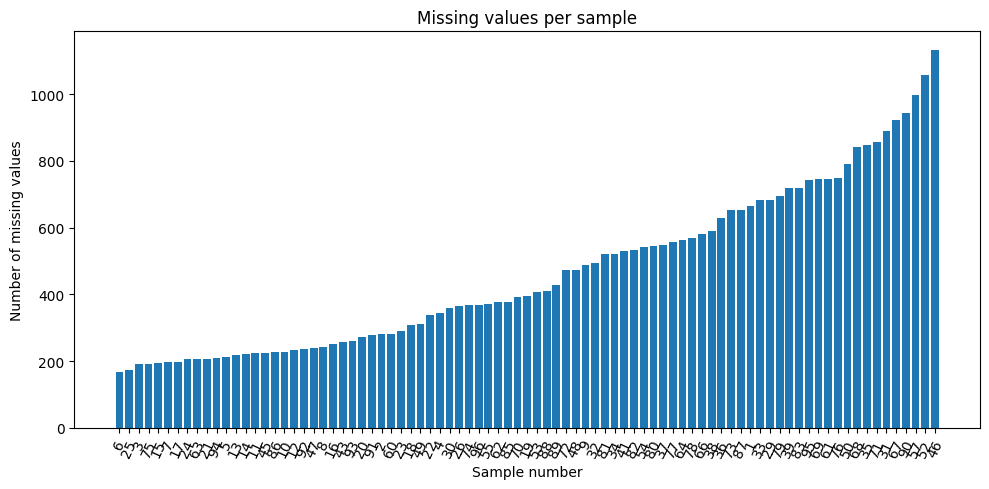

In [43]:
null_values = df.drop(columns='Genes').isnull().sum()
null_values = null_values.sort_values(ascending=True)
labels = null_values.index.str.replace('Sample ', '', regex=False)
plt.figure(figsize=(10, 5))
plt.bar(labels, null_values.values)
plt.xticks(rotation= 65, fontsize=10)
plt.ylabel("Number of missing values")
plt.xlabel("Sample number")
plt.title("Missing values per sample")
plt.tight_layout()
plt.show()

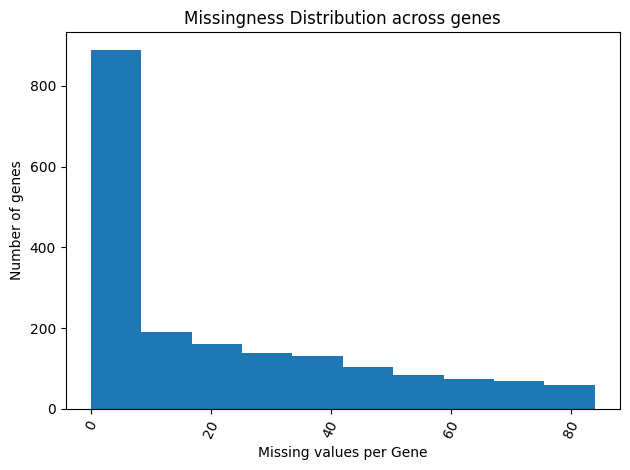

In [48]:

gene_missing = df.drop(columns='Genes').isna().sum(axis=1)
gene_missing = gene_missing.sort_values(ascending=True)

plt.hist(gene_missing)
plt.xticks(rotation= 65, fontsize=10)
plt.ylabel("Number of genes")
plt.xlabel("Missing values per Gene")
plt.title("Missingness Distribution across genes")
plt.tight_layout()
plt.show()

In [54]:
values = df.values.flatten()
values = values[~np.isnan(values)]
plt.hist(values, bins=100)
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.title("Overall intensity distribution")
plt.show()
    

TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

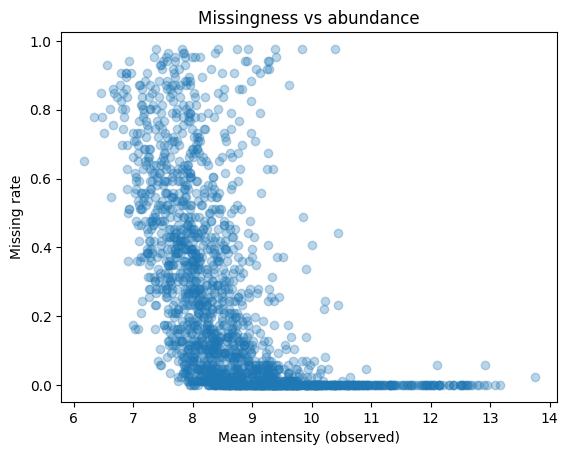

In [57]:
gene_mean = df.drop(columns= "Genes").mean(axis=1, skipna=True)
gene_missing = df.isna().mean(axis=1)

plt.scatter(gene_mean, gene_missing, alpha=0.3)
plt.xlabel("Mean intensity (observed)")
plt.ylabel("Missing rate")
plt.title("Missingness vs abundance")
plt.show()

In [19]:
for row,col in df.iterrows():
    print( col['Genes'], col.isna().sum())

MAPK1 17
F8A1 45
SUGT1 31
RBX1 26
PEPD 22
EEF1G 0
VTA1 20
LSM5 18
PFDN1 14
PSMD5 3
RAN 0
SMIM5 38
LGALS1 2
SLC35A4 17
CAPZA1 0
PPP1CB 7
NAP1L4 0
PPP1CC 72
CAPZA2 1
CAP1 0
GAS2L1 34
CALM1 0
APRT 1
RPS12 39
CLIC1 0
USP15 8
ABI1 3
DYNLRB1 24
SNAPIN 7
CALML5 45
TPM3 0
PSMF1 36
BRK1 3
LGALSL 4
DBN1 0
PFN1 0
TWF2 24
STK24 1
CLIC4 36
LIMS1 0
GLRX 7
MYH9 0
VCP 0
CFL1 0
DSTN 15
ANXA3 26
GNG2 70
CA1 8
ATP6V1G1 12
KRT6A 0
RAB14 0
GNB5 78
EEF1D 1
PIP4K2A 0
FABP5 1
MAPRE2 1
MAPRE1 0
MYL6 0
MTPN 32
ACTB 0
ACTG1 2
YWHAH 0
CAVIN2 0
RAB11B 0
NRGN 28
ILK 0
YWHAE 0
MTURN 4
YWHAZ 0
YWHAB 15
SNAP23 0
SERPINB12 1
ELOB 2
COPZ1 4
DNM1L 4
PSMC4 16
YWHAQ 0
DCTN5 44
SULT1A1 20
KPNB1 0
DIAPH1 1
SERPINB1 2
TALDO1 15
PRKAR1A 5
ACTR1A 3
TKT 22
TMEM40 4
PSMB2 0
ATG3 0
SMIM1 27
CPPED1 60
RAB6B 1
KRT2 0
PTMA 0
MAPK1IP1L 63
TMSB4X 3
CAPZB 0
PPP1CA 4
GMFG 16
GNB1 0
H1-4 42
H1-5 76
VASP 1
RPSA 51
GNG5 4
PSMB3 0
RNH1 6
SDCBP 3
PDLIM5 5
MAPK14 2
KRT1 0
PSMA3 0
BLMH 13
ALDH1A1 55
RAB6A 5
VAMP3 3
STX7 2
ARPC4 1
RAB27B 0
GYG1 